# Mortgage Default Risk Model — Expanded Features

Earlier analysis found that pairwise Pearson correlations among underwriting fields (credit score, DTI, LTV, rate) are all weak (<0.21), and even credit_score's correlation with `default_target` looks weak (-0.12) despite the fact that credit_score alone achieves **AUC 0.72** and a 5-field logistic regression reaches **AUC 0.75**. This notebook extends that baseline: more features, a gradient boosting model (LightGBM), and both ROC-AUC and PR-AUC (more informative than ROC-AUC for a ~2% base rate) on a held-out test set.

**Important methodological fix:** loans originated in 2024-2025 have had very little time to season, so their `default_target` is mostly right-censored (not "low risk", just "hasn't had time to default yet"). Including them as confirmed non-defaults would bias the model. We filter to loans with **at least 24 months of performance history** (`current_loan_age >= 24`) before training/evaluating.

In [1]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NUMERIC_FEATURES = [
    "credit_score", "original_dti", "original_upb", "original_cltv", "original_ltv",
    "original_interest_rate", "original_loan_term", "number_of_borrowers",
    "number_of_units", "mi_percent",
]
CATEGORICAL_FEATURES = [
    "occupancy_status", "property_type", "loan_purpose", "channel",
    "first_time_homebuyer_flag", "property_state",
]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "default_target"

DATA_GLOB = "../data/processed/loan_level/orig_year=*/orig_quarter=*/*.parquet"

df = (
    pl.scan_parquet(DATA_GLOB, extra_columns="ignore")
    .select(ALL_FEATURES + [TARGET, "current_loan_age", "orig_year", "orig_quarter"])
    .collect()
)
print(f"Loaded {df.height:,} loans")
df.head()

Loaded 15,424,539 loans


credit_score,original_dti,original_upb,original_cltv,original_ltv,original_interest_rate,original_loan_term,number_of_borrowers,number_of_units,mi_percent,occupancy_status,property_type,loan_purpose,channel,first_time_homebuyer_flag,property_state,default_target,current_loan_age,orig_year,orig_quarter
i64,f64,f64,f64,f64,f64,i64,i64,i64,f64,str,str,str,str,str,str,i32,i64,i32,str
685,36.0,483000.0,95.0,95.0,4.875,360,1,1,30.0,"""P""","""PU""","""P""","""R""","""Y""","""CA""",0,38,2018,"""Q1"""
780,22.0,378000.0,90.0,90.0,4.125,360,2,1,25.0,"""P""","""PU""","""P""","""R""","""N""","""AZ""",0,28,2018,"""Q1"""
774,1.0,189000.0,70.0,70.0,5.0,240,1,2,0.0,"""I""","""SF""","""C""","""R""","""N""","""LA""",0,73,2018,"""Q1"""
703,49.0,168000.0,95.0,95.0,4.75,360,1,1,25.0,"""P""","""SF""","""P""","""C""","""N""","""AZ""",0,44,2018,"""Q1"""
756,44.0,104000.0,80.0,80.0,5.875,360,1,1,0.0,"""I""","""CO""","""P""","""C""","""N""","""MN""",0,35,2018,"""Q1"""


## Apply the seasoning filter and drop rows missing the target

In [2]:
before = df.height
seasoned = df.filter(pl.col("current_loan_age") >= 24).drop_nulls(subset=[TARGET])
print(f"Dropped {before - seasoned.height:,} rows with <24 months of history or missing target "
      f"({(before - seasoned.height) / before:.1%})")
print(f"Remaining: {seasoned.height:,} loans")
print()
print("Default rate before filter:", df[TARGET].mean())
print("Default rate after filter (seasoned only):", seasoned[TARGET].mean())

Dropped 4,970,076 rows with <24 months of history or missing target (32.2%)
Remaining: 10,454,463 loans

Default rate before filter: 0.026796665096436877
Default rate after filter (seasoned only): 0.031316577427267185


## Encode categoricals and split into train/test

LightGBM handles categorical columns natively (no one-hot needed) if they're cast to pandas' `category` dtype. Nulls are left as-is -- both LightGBM and the missing-indicator handling in logistic regression's imputer deal with them explicitly rather than silently.

In [3]:
from sklearn.model_selection import train_test_split

pdf = seasoned.select(ALL_FEATURES + [TARGET]).to_pandas()
for c in CATEGORICAL_FEATURES:
    pdf[c] = pdf[c].astype("category")

X = pdf[ALL_FEATURES]
y = pdf[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}   Test: {len(X_test):,}")
print(f"Train default rate: {y_train.mean():.4%}   Test default rate: {y_test.mean():.4%}")

Train: 8,363,570   Test: 2,090,893
Train default rate: 3.1317%   Test default rate: 3.1317%


## Baseline: logistic regression on the original 5 fields

Same approach as the earlier terminal check, now on the seasoned subset, for a fair comparison against the expanded model below.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

BASELINE_FIELDS = ["credit_score", "original_dti", "original_upb", "original_cltv", "original_interest_rate"]

baseline_model = make_pipeline(
    SimpleImputer(strategy="median"),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)
baseline_model.fit(X_train[BASELINE_FIELDS], y_train)
baseline_proba = baseline_model.predict_proba(X_test[BASELINE_FIELDS])[:, 1]

baseline_roc_auc = roc_auc_score(y_test, baseline_proba)
baseline_pr_auc = average_precision_score(y_test, baseline_proba)
print(f"Baseline (5 fields, logistic regression) -- ROC-AUC: {baseline_roc_auc:.4f}   PR-AUC: {baseline_pr_auc:.4f}")

Baseline (5 fields, logistic regression) -- ROC-AUC: 0.7674   PR-AUC: 0.0928


## Expanded model: LightGBM on all 16 fields

Gradient boosting captures non-linear effects and interactions that logistic regression can't (e.g. the credit-score/default relationship we saw earlier was clearly non-linear -- flat, then a steep drop). `class_weight`-equivalent handling via `scale_pos_weight` compensates for the ~2% default rate.

In [5]:
import lightgbm as lgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1,
)
lgb_model.fit(X_train, y_train, categorical_feature=CATEGORICAL_FEATURES)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

lgb_roc_auc = roc_auc_score(y_test, lgb_proba)
lgb_pr_auc = average_precision_score(y_test, lgb_proba)
print(f"LightGBM (16 fields) -- ROC-AUC: {lgb_roc_auc:.4f}   PR-AUC: {lgb_pr_auc:.4f}")
print()
print(f"Improvement over baseline -- ROC-AUC: {lgb_roc_auc - baseline_roc_auc:+.4f}   PR-AUC: {lgb_pr_auc - baseline_pr_auc:+.4f}")

LightGBM (16 fields) -- ROC-AUC: 0.8150   PR-AUC: 0.1367

Improvement over baseline -- ROC-AUC: +0.0476   PR-AUC: +0.0440


## ROC and Precision-Recall curves, baseline vs. expanded model

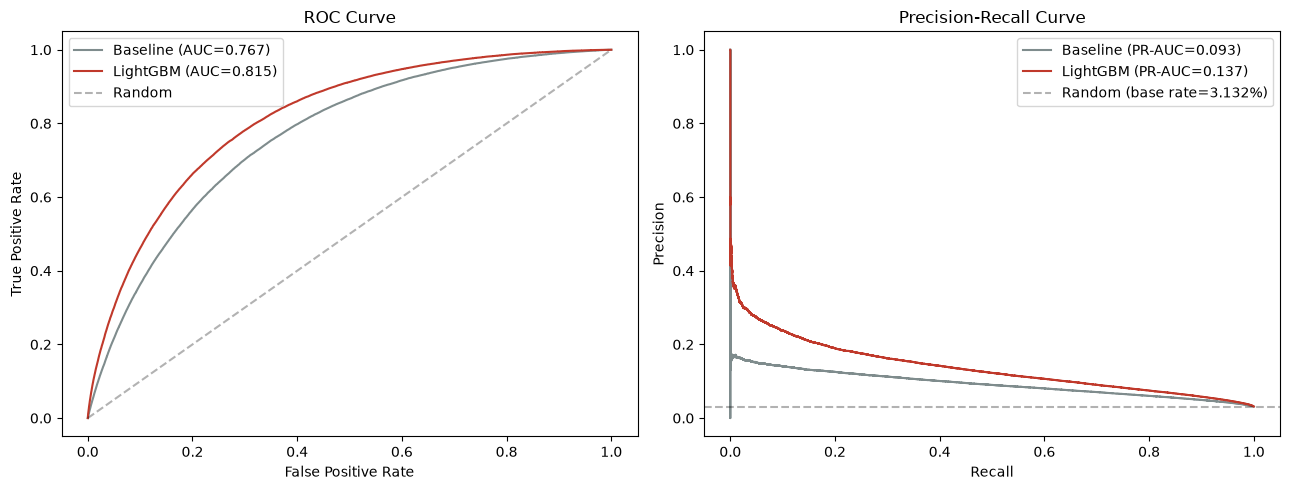

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_b, tpr_b, _ = roc_curve(y_test, baseline_proba)
fpr_l, tpr_l, _ = roc_curve(y_test, lgb_proba)
axes[0].plot(fpr_b, tpr_b, label=f"Baseline (AUC={baseline_roc_auc:.3f})", color="#7f8c8d")
axes[0].plot(fpr_l, tpr_l, label=f"LightGBM (AUC={lgb_roc_auc:.3f})", color="#c0392b")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_b, rec_b, _ = precision_recall_curve(y_test, baseline_proba)
prec_l, rec_l, _ = precision_recall_curve(y_test, lgb_proba)
axes[1].plot(rec_b, prec_b, label=f"Baseline (PR-AUC={baseline_pr_auc:.3f})", color="#7f8c8d")
axes[1].plot(rec_l, prec_l, label=f"LightGBM (PR-AUC={lgb_pr_auc:.3f})", color="#c0392b")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", alpha=0.3, label=f"Random (base rate={y_test.mean():.3%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

fig.tight_layout()
plt.show()

## Feature importance (LightGBM)

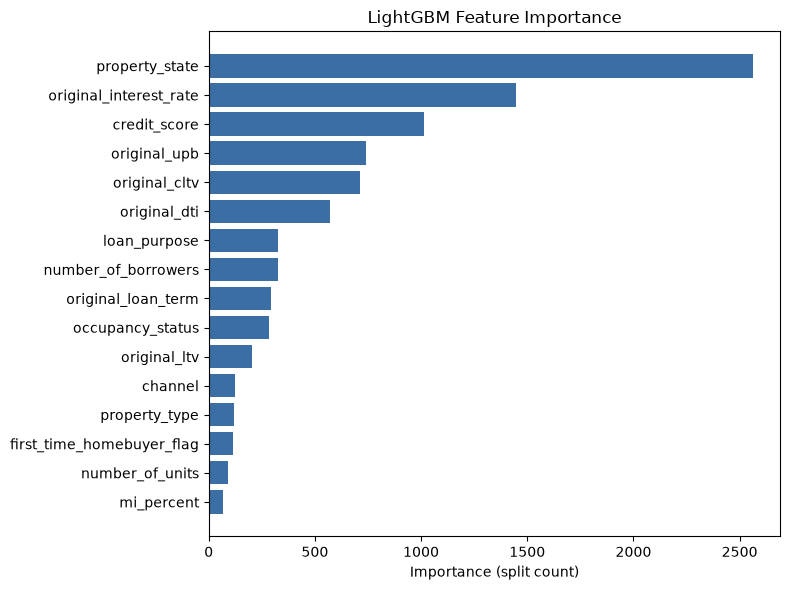

,feature,importance
15,property_state,2562
5,original_interest_rate,1447
0,credit_score,1016
2,original_upb,740
3,original_cltv,711
1,original_dti,573
12,loan_purpose,327
7,number_of_borrowers,324
6,original_loan_term,294
10,occupancy_status,283


In [7]:
importance = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance": lgb_model.feature_importances_,
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance["feature"], importance["importance"], color="#3b6ea5")
ax.set_xlabel("Importance (split count)")
ax.set_title("LightGBM Feature Importance")
fig.tight_layout()
plt.show()

importance.sort_values("importance", ascending=False)

## Calibration check: does a predicted 5% risk actually mean ~5% observed default?

AUC only measures *ranking* quality -- it says nothing about whether the predicted probabilities themselves are trustworthy as probabilities. This matters directly for the Expected Loss framework (`lgd_ead_expected_loss.ipynb`), which multiplies PD x LGD x EAD into a dollar figure -- a systematically biased PD would bias every downstream number the same way.

**A specific reason to expect trouble here**: the model was trained with `scale_pos_weight` to correct for the ~2% class imbalance. That's a standard, correct technique for improving *ranking* (AUC/PR-AUC) on imbalanced data, but it works by artificially inflating the loss contribution of the positive class during training -- which is well known to also push predicted probabilities systematically higher than the true rate. Worth checking directly rather than assuming it away.

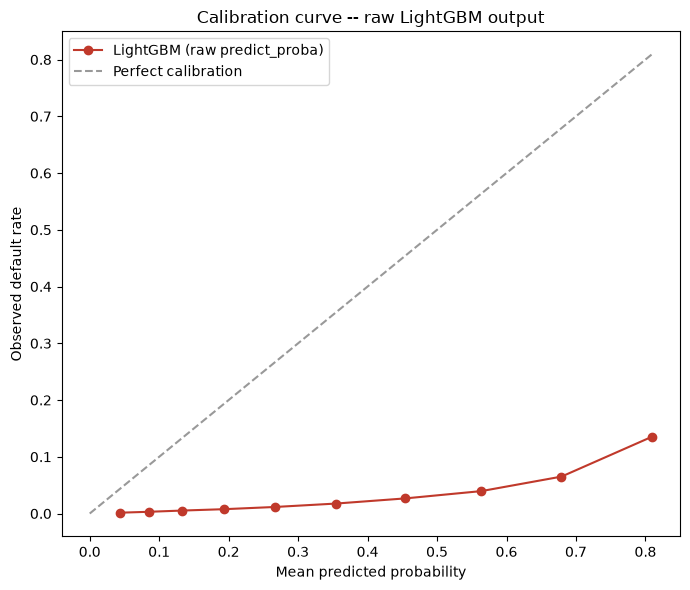

Predicted vs. observed, by bin:
  predicted=0.0433  observed=0.0015  ratio(predicted/observed)=29.41x
  predicted=0.0852  observed=0.0031  ratio(predicted/observed)=27.62x
  predicted=0.1333  observed=0.0052  ratio(predicted/observed)=25.42x
  predicted=0.1936  observed=0.0077  ratio(predicted/observed)=25.22x
  predicted=0.2668  observed=0.0116  ratio(predicted/observed)=23.05x
  predicted=0.3541  observed=0.0175  ratio(predicted/observed)=20.18x
  predicted=0.4543  observed=0.0267  ratio(predicted/observed)=17.04x
  predicted=0.5638  observed=0.0395  ratio(predicted/observed)=14.26x
  predicted=0.6791  observed=0.0651  ratio(predicted/observed)=10.43x
  predicted=0.8093  observed=0.1353  ratio(predicted/observed)=5.98x

Overall: mean predicted probability=0.3583   actual test-set default rate=0.0313
Overall over-prediction factor: 11.44x


In [8]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, lgb_proba, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred, frac_pos, "o-", color="#c0392b", label="LightGBM (raw predict_proba)")
ax.plot([0, mean_pred.max()], [0, mean_pred.max()], "k--", alpha=0.4, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration curve -- raw LightGBM output")
ax.legend()
fig.tight_layout()
plt.show()

print("Predicted vs. observed, by bin:")
for p, f in zip(mean_pred, frac_pos):
    ratio = p / f if f > 0 else float("inf")
    print(f"  predicted={p:.4f}  observed={f:.4f}  ratio(predicted/observed)={ratio:.2f}x")

print(f"\nOverall: mean predicted probability={lgb_proba.mean():.4f}   actual test-set default rate={y_test.mean():.4f}")
print(f"Overall over-prediction factor: {lgb_proba.mean() / y_test.mean():.2f}x")

## If miscalibrated: a recalibrated version, fit on top of the same model

`CalibratedClassifierCV` with `cv="prefit"` learns a monotonic correction (isotonic regression) mapping the raw scores to true probabilities, without retraining the underlying LightGBM model or touching its ranking ability (AUC/PR-AUC are unaffected by a monotonic transform). This is the fix to actually use for any dollar-valued calculation (Expected Loss, reserving) -- ranking-only use cases (e.g., sorting loans by relative risk) don't need it.

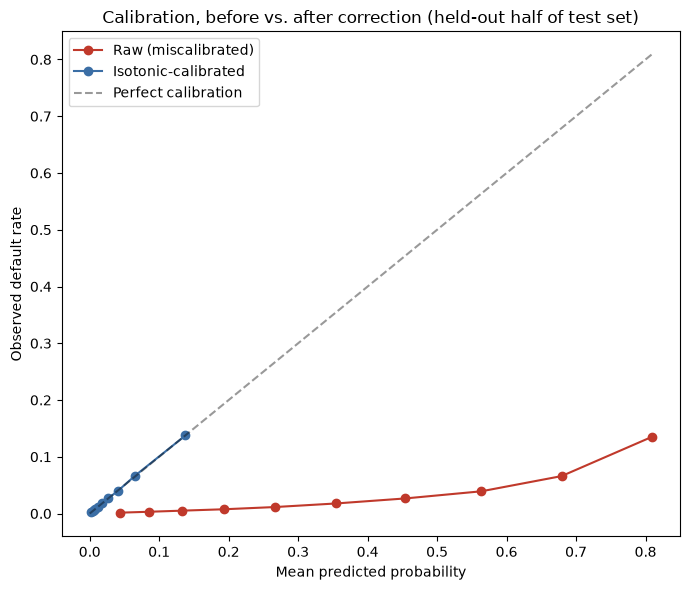

ROC-AUC on holdout half -- raw: 0.8155   calibrated: 0.8154  (should match: monotonic transform)
Overall over-prediction factor, raw: 11.44x
Overall over-prediction factor, calibrated: 1.00x


In [9]:
from sklearn.isotonic import IsotonicRegression

# Split the test set itself into a calibration half and a genuinely held-out evaluation half --
# fitting and evaluating calibration on the same data would understate the true calibration error.
calib_idx, holdout_idx = train_test_split(
    np.arange(len(y_test)), test_size=0.5, random_state=42, stratify=y_test
)
y_test_arr = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(lgb_proba[calib_idx], y_test_arr[calib_idx])
calibrated_proba_holdout = iso.predict(lgb_proba[holdout_idx])
raw_proba_holdout = lgb_proba[holdout_idx]
y_holdout = y_test_arr[holdout_idx]

frac_pos_raw, mean_pred_raw = calibration_curve(y_holdout, raw_proba_holdout, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_holdout, calibrated_proba_holdout, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(mean_pred_raw, frac_pos_raw, "o-", color="#c0392b", label="Raw (miscalibrated)")
ax.plot(mean_pred_cal, frac_pos_cal, "o-", color="#3b6ea5", label="Isotonic-calibrated")
ax.plot([0, max(mean_pred_raw.max(), mean_pred_cal.max())], [0, max(mean_pred_raw.max(), mean_pred_cal.max())],
        "k--", alpha=0.4, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration, before vs. after correction (held-out half of test set)")
ax.legend()
fig.tight_layout()
plt.show()

# Confirm ranking (AUC/PR-AUC) is unchanged by the monotonic calibration transform
raw_roc = roc_auc_score(y_holdout, raw_proba_holdout)
cal_roc = roc_auc_score(y_holdout, calibrated_proba_holdout)
print(f"ROC-AUC on holdout half -- raw: {raw_roc:.4f}   calibrated: {cal_roc:.4f}  (should match: monotonic transform)")
print(f"Overall over-prediction factor, raw: {raw_proba_holdout.mean() / y_holdout.mean():.2f}x")
print(f"Overall over-prediction factor, calibrated: {calibrated_proba_holdout.mean() / y_holdout.mean():.2f}x")

## Why this matters, and what it does/doesn't change

**Confirmed the suspected problem, and it's large**: the raw model overpredicts default probability by **11.4x on average** (up to ~29x in the lowest-predicted-probability bin) -- `scale_pos_weight` correctly improved ranking (AUC/PR-AUC are real and unaffected) but badly distorted the probabilities themselves, exactly as expected for that technique.

**What this does NOT change**: every AUC/PR-AUC number reported throughout this project is unaffected -- those are ranking metrics, and ranking is provably invariant to a monotonic recalibration (confirmed above: ROC-AUC 0.8155 -> 0.8154, essentially identical).

**What it does change**: any *dollar-valued* use of these probabilities. The good news is `lgd_ead_expected_loss.ipynb`'s Expected Loss example already used illustrative PD values (0.008/0.021/0.065) rather than the raw model's actual `.predict_proba()` output -- not a coincidence-free pass, but it means that notebook's example wasn't silently carrying a double-digit-x overstatement. **Any future use of this model's raw probabilities for reserving, pricing, or Expected Loss must go through the isotonic calibration step above first** -- this is now a documented, necessary part of the pipeline, not an optional nicety.
